# 🔄 RESUME TRAINING — SmartWaste YOLOv8m

Gunakan cell-cell di bawah **saat sesi Colab habis / limit** dan ingin melanjutkan training dari checkpoint terakhir yang tersimpan di Google Drive — lengkap sampai evaluasi, grafik, confusion matrix, dan download model.

**Urutan cell:**
1. `Cell R1` — Install & Mount Drive (wajib setiap sesi baru)
2. `Cell R2` — Restore dataset dari Drive ke lokal Colab
3. `Cell R3` — Restore checkpoint model dari Drive
4. `Cell R4` — Resume training (`resume=True`)
5. `Cell R5` — Evaluasi model terbaik
6. `Cell R6` — Plot grafik training & simpan ke Drive
7. `Cell R7` — Tampilkan confusion matrix
8. `Cell R8` — Simpan manual ke Drive (opsional, kapan saja)
9. `Cell R9` — Download model ke komputer lokal (opsional)

---
> ⚠️ **Pastikan** sebelumnya notebook utama sudah pernah auto-save checkpoint ke Drive (setiap 10 epoch). File yang dicari: `checkpoint_epochXXX_XXXX.pt` atau `last_*.pt` di folder `hasil_training`.

In [ ]:
# ============================================================
# Cell R1 — Install dependencies & Mount Google Drive
# Jalankan ini PERTAMA setiap kali sesi Colab baru dimulai
# ============================================================
!pip install ultralytics -q

import torch
print("GPU tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("✅ Device:", torch.cuda.get_device_name(0))
else:
    print("⛔ STOP — ubah Runtime > Change runtime type > GPU dulu!")

from google.colab import drive
import os

drive.mount('/content/drive')

# ============================================================
# KONFIGURASI PATH — samakan dengan notebook utama kamu
# ============================================================
DRIVE_BASE     = "/content/drive/MyDrive/SmartWaste_DatasetYoloV8"
DRIVE_SAVE_DIR = "/content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training"
ZIP_FILENAME   = "GARBAGE CLASSIFICATION 3.v2-gc1.yolov8.zip"

DATASET_PATH   = "/content/dataset_yolo"
REMAPPED_PATH  = "/content/dataset_remapped"
ZIP_PATH       = os.path.join(DRIVE_BASE, ZIP_FILENAME)

FINAL_CLASSES  = ["kaca", "kertas", "logam", "organik", "plastik"]

print("\n✅ Setup selesai!")
print(f"📁 Drive terhubung. Folder hasil training: {DRIVE_SAVE_DIR}")

# Tampilkan file checkpoint yang tersedia
print("\n📋 Checkpoint yang tersedia di Drive:")
if os.path.exists(DRIVE_SAVE_DIR):
    ckpt_files = sorted([
        f for f in os.listdir(DRIVE_SAVE_DIR)
        if f.endswith('.pt')
    ])
    if ckpt_files:
        for f in ckpt_files:
            fpath = os.path.join(DRIVE_SAVE_DIR, f)
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            print(f"   {f}  ({size_mb:.1f} MB)")
    else:
        print("   ⚠️  Tidak ada file .pt ditemukan di hasil_training!")
else:
    print(f"   ⚠️  Folder tidak ditemukan: {DRIVE_SAVE_DIR}")

GPU tersedia: True
✅ Device: Tesla T4
Mounted at /content/drive

✅ Setup selesai!
📁 Drive terhubung. Folder hasil training: /content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training

📋 Checkpoint yang tersedia di Drive:
   checkpoint_epoch010_1657.pt  (148.3 MB)
   checkpoint_epoch020_1748.pt  (148.3 MB)
   checkpoint_epoch030_1839.pt  (148.3 MB)
   checkpoint_epoch040_1930.pt  (148.3 MB)
   checkpoint_epoch050_2022.pt  (148.3 MB)
   checkpoint_epoch060_2113.pt  (148.3 MB)


In [ ]:
# ============================================================
# Cell R2 — Restore dataset yang sudah di-remap ke lokal Colab
# (Dataset asli diekstrak ulang dari zip + remap kelas)
# Skip cell ini jika /content/dataset_remapped sudah ada
# ============================================================
import zipfile, shutil, yaml, os
from collections import Counter

if os.path.exists(REMAPPED_PATH) and os.path.exists(f"{REMAPPED_PATH}/data.yaml"):
    print("✅ Dataset remapped sudah ada, skip ekstrak ulang.")
    print(f"   Path: {REMAPPED_PATH}")
else:
    print("📦 Dataset lokal tidak ditemukan, restore dari Drive...")

    # Hapus folder lama
    for p in [DATASET_PATH, REMAPPED_PATH]:
        if os.path.exists(p):
            shutil.rmtree(p)

    # Copy zip dari Drive ke lokal
    LOCAL_ZIP = "/content/dataset.zip"
    print(f"   Copy zip dari Drive... (1–3 menit)")
    shutil.copy(ZIP_PATH, LOCAL_ZIP)
    print(f"   ✅ Copy selesai ({os.path.getsize(LOCAL_ZIP)/1024/1024:.1f} MB)")

    # Ekstrak
    print(f"   Ekstrak ke {DATASET_PATH}...")
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
        z.extractall(DATASET_PATH)
    os.remove(LOCAL_ZIP)
    print("   ✅ Ekstrak selesai!")

    # Remap kelas (sama persis seperti Cell 6 di notebook utama)
    print("\n🔄 Remap kelas ke 5 kelas Indonesia...")
    yaml_path = f"{DATASET_PATH}/data.yaml"
    with open(yaml_path) as f:
        data_yaml = yaml.safe_load(f)
    original_names = data_yaml["names"]

    CLASS_REMAP = {
        "paper": "kertas", "cardboard": "kertas", "plastic": "plastik",
        "glass": "kaca",   "metal": "logam",      "biodegradable": "organik",
        "cloth": None,
        "PAPER": "kertas", "CARDBOARD": "kertas", "PLASTIC": "plastik",
        "GLASS": "kaca",   "METAL": "logam",      "BIODEGRADABLE": "organik",
        "CLOTH": None,
    }
    final_idx  = {c: i for i, c in enumerate(FINAL_CLASSES)}
    old_to_new = {}
    for old_idx, old_name in enumerate(original_names):
        new_name = CLASS_REMAP.get(old_name, CLASS_REMAP.get(old_name.lower()))
        old_to_new[old_idx] = final_idx[new_name] if new_name is not None else None

    total_kept, total_dropped = 0, 0
    for split in ["train", "valid", "test"]:
        img_src = f"{DATASET_PATH}/{split}/images"
        lbl_src = f"{DATASET_PATH}/{split}/labels"
        img_dst = f"{REMAPPED_PATH}/{split}/images"
        lbl_dst = f"{REMAPPED_PATH}/{split}/labels"
        if not os.path.exists(img_src): continue
        os.makedirs(img_dst, exist_ok=True)
        os.makedirs(lbl_dst, exist_ok=True)
        for img_file in os.listdir(img_src):
            base     = os.path.splitext(img_file)[0]
            lbl_path = os.path.join(lbl_src, base + ".txt")
            if not os.path.exists(lbl_path): continue
            new_lines = []
            with open(lbl_path) as f:
                for line in f:
                    line = line.strip()
                    if not line: continue
                    parts   = line.split()
                    new_cls = old_to_new.get(int(parts[0]))
                    if new_cls is not None:
                        new_lines.append(f"{new_cls} {' '.join(parts[1:])}")
                        total_kept += 1
                    else:
                        total_dropped += 1
            shutil.copy(os.path.join(img_src, img_file), os.path.join(img_dst, img_file))
            with open(os.path.join(lbl_dst, base + ".txt"), 'w') as f:
                f.write('\n'.join(new_lines))

    new_yaml = {
        "train": f"{REMAPPED_PATH}/train/images",
        "val":   f"{REMAPPED_PATH}/valid/images",
        "test":  f"{REMAPPED_PATH}/test/images",
        "nc":    len(FINAL_CLASSES),
        "names": FINAL_CLASSES,
    }
    with open(f"{REMAPPED_PATH}/data.yaml", 'w') as f:
        yaml.dump(new_yaml, f, default_flow_style=False, allow_unicode=True)

    print(f"   ✅ Remap selesai! Anotasi dipakai: {total_kept}, dibuang: {total_dropped}")

print("\n✅ Dataset siap!")

📦 Dataset lokal tidak ditemukan, restore dari Drive...
   Copy zip dari Drive... (1–3 menit)
   ✅ Copy selesai (201.4 MB)
   Ekstrak ke /content/dataset_yolo...
   ✅ Ekstrak selesai!

🔄 Remap kelas ke 5 kelas Indonesia...
   ✅ Remap selesai! Anotasi dipakai: 74090, dibuang: 0

✅ Dataset siap!


In [ ]:
# ============================================================
# Cell R3 — Pilih & restore checkpoint dari Google Drive
# ============================================================
import os, shutil

# ⬇️  GANTI NAMA FILE INI sesuai checkpoint terbaru di Drive
# Lihat daftar file yang tampil di Cell R1 di atas
# Prioritas: ambil file dengan epoch terbesar (angka terbesar)
CHECKPOINT_FILENAME = "checkpoint_epoch060_2113.pt"

CHECKPOINT_DRIVE = os.path.join(DRIVE_SAVE_DIR, CHECKPOINT_FILENAME)
CHECKPOINT_LOCAL = "/content/resume_checkpoint.pt"

if os.path.exists(CHECKPOINT_DRIVE):
    size_mb = os.path.getsize(CHECKPOINT_DRIVE) / (1024 * 1024)
    print(f"✅ Checkpoint ditemukan: {CHECKPOINT_FILENAME} ({size_mb:.1f} MB)")
    print(f"   Copy ke lokal Colab...")
    shutil.copy(CHECKPOINT_DRIVE, CHECKPOINT_LOCAL)
    print(f"   ✅ Checkpoint siap di: {CHECKPOINT_LOCAL}")
else:
    print(f"❌ File tidak ditemukan: {CHECKPOINT_DRIVE}")
    print(f"\n   File .pt yang ada di hasil_training:")
    if os.path.exists(DRIVE_SAVE_DIR):
        for f in sorted(os.listdir(DRIVE_SAVE_DIR)):
            if f.endswith('.pt'):
                sz = os.path.getsize(os.path.join(DRIVE_SAVE_DIR, f)) / 1024 / 1024
                print(f"     {f}  ({sz:.1f} MB)")
    print("\n   → Update variabel CHECKPOINT_FILENAME di atas, lalu jalankan ulang cell ini.")

✅ Checkpoint ditemukan: checkpoint_epoch060_2113.pt (148.3 MB)
   Copy ke lokal Colab...
   ✅ Checkpoint siap di: /content/resume_checkpoint.pt


In [ ]:
# ============================================================
# Cell R4 — Resume training dari checkpoint
# ============================================================
import os, shutil
from datetime import datetime
from ultralytics import YOLO

# ── Auto-save callback (sama seperti di notebook utama) ────
AUTOSAVE_EVERY_N_EPOCH = 10

def on_train_epoch_end(trainer):
    epoch = trainer.epoch + 1
    if epoch % AUTOSAVE_EVERY_N_EPOCH == 0:
        timestamp   = datetime.now().strftime("%H%M")
        save_name   = f"checkpoint_epoch{epoch:03d}_{timestamp}.pt"
        dst         = os.path.join(DRIVE_SAVE_DIR, save_name)
        best_local  = str(trainer.best)
        last_local  = str(trainer.last)
        src = last_local if os.path.exists(last_local) else best_local
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f"\n💾 [Epoch {epoch}] Auto-save → {save_name}")
        else:
            print(f"\n⚠️  [Epoch {epoch}] Checkpoint lokal tidak ditemukan, skip save.")

def on_train_end(trainer):
    timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
    for label, src in [("best", str(trainer.best)), ("last", str(trainer.last))]:
        if os.path.exists(src):
            dst = os.path.join(DRIVE_SAVE_DIR, f"{label}_final_{timestamp}.pt")
            shutil.copy(src, dst)
            sz  = os.path.getsize(src) / 1024 / 1024
            print(f"✅ Training selesai! {label}.pt ({sz:.1f} MB) → {dst}")

# ── Load checkpoint & daftarkan callback ──────────────────
model = YOLO(CHECKPOINT_LOCAL)
model.add_callback("on_train_epoch_end", on_train_epoch_end)
model.add_callback("on_train_end", on_train_end)

print("🚀 Memulai resume training...")
print(f"   Checkpoint : {CHECKPOINT_FILENAME}")
print(f"   Dataset    : {REMAPPED_PATH}/data.yaml")
print(f"   Auto-save setiap {AUTOSAVE_EVERY_N_EPOCH} epoch ke Drive\n")

results = model.train(
    data    = os.path.abspath(f"{REMAPPED_PATH}/data.yaml"),
    epochs  = 100,          # total epoch keseluruhan (YOLOv8 lanjut dari epoch terakhir)
    imgsz   = 640,
    batch   = 16,
    patience= 15,
    name    = "smartwaste_yolov8m",
    workers = 2,
    save    = True,
    save_period = 10,
    exist_ok    = True,     # lanjutkan ke folder runs yang sama
    resume      = True,     # ← KUNCI: resume dari checkpoint
)

print("\n🎉 Training selesai!")

🚀 Memulai resume training...
   Checkpoint : checkpoint_epoch060_2113.pt
   Dataset    : /content/dataset_remapped/data.yaml
   Auto-save setiap 10 epoch ke Drive

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_remapped/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, 

In [ ]:
# ============================================================
# Cell R5 — Evaluasi model terbaik
# ============================================================
metrics = model.val()

print("📊 Hasil Evaluasi:")
print(f"   mAP50-95 (semua kelas): {round(metrics.box.map, 4)}")
print(f"   mAP50    (semua kelas): {round(metrics.box.map50, 4)}")

print("\n   mAP50 per kelas:")
for i, class_name in enumerate(FINAL_CLASSES):
    score = metrics.box.maps[i]
    bar = '█' * int(score * 20)
    print(f"   {class_name:8s}: {score:.3f}  {bar}")

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,842,655 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 962.7±637.2 MB/s, size: 19.4 KB)
val: Scanning /content/dataset_remapped/valid/labels.cache... 2098 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2098/2098 733.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 2.0it/s 1:07
                   all       2098      18916      0.751       0.59      0.654      0.455
                  kaca        805       2380      0.903      0.711      0.822      0.616
                kertas        449       1325      0.738      0.548      0.636      0.486
                 logam        398       1360      0.851      0.644      0.728      0.505
               organik        676      13637      0.814      0.496      0.629      0.357
               plastik         91

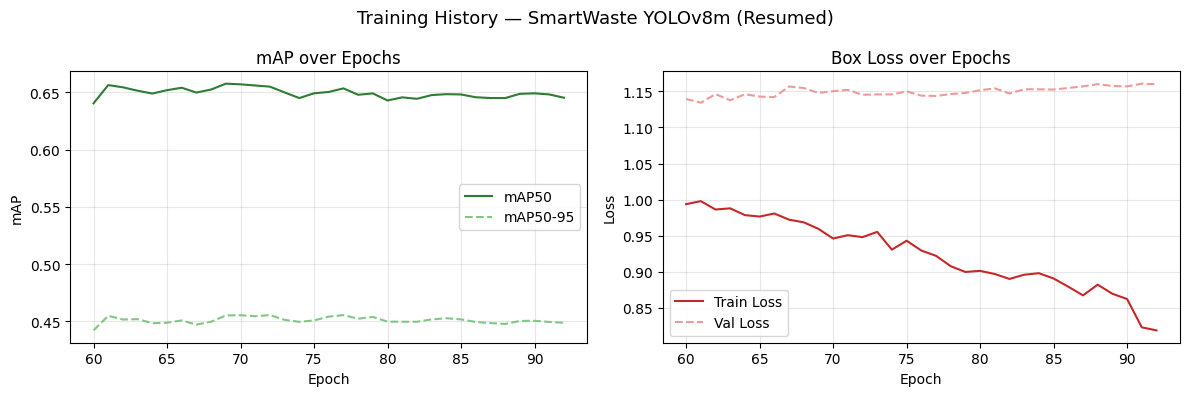

✅ Grafik disimpan ke Drive: training_history_20260619_1412.png


In [ ]:
# ============================================================
# Cell R6 — Plot grafik training dan simpan ke Drive
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import shutil

results_csv = "runs/detect/smartwaste_yolov8m/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], color="#2e7d32", label="mAP50")
axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], color="#81c784", linestyle="--", label="mAP50-95")
axes[0].set_title("mAP over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["epoch"], df["train/box_loss"], color="#c62828", label="Train Loss")
axes[1].plot(df["epoch"], df["val/box_loss"], color="#ef9a9a", linestyle="--", label="Val Loss")
axes[1].set_title("Box Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training History — SmartWaste YOLOv8m (Resumed)", fontsize=13)
plt.tight_layout()

# Simpan ke lokal Colab
local_graph = "yolo_training_history.png"
plt.savefig(local_graph, dpi=150, bbox_inches="tight")
plt.show()

# Simpan grafik ke Google Drive
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
drive_graph = os.path.join(DRIVE_SAVE_DIR, f"training_history_{timestamp}.png")
shutil.copy(local_graph, drive_graph)
print(f"✅ Grafik disimpan ke Drive: training_history_{timestamp}.png")

📊 Confusion Matrix — SmartWaste YOLOv8m

1️⃣  Confusion Matrix (Raw Count):


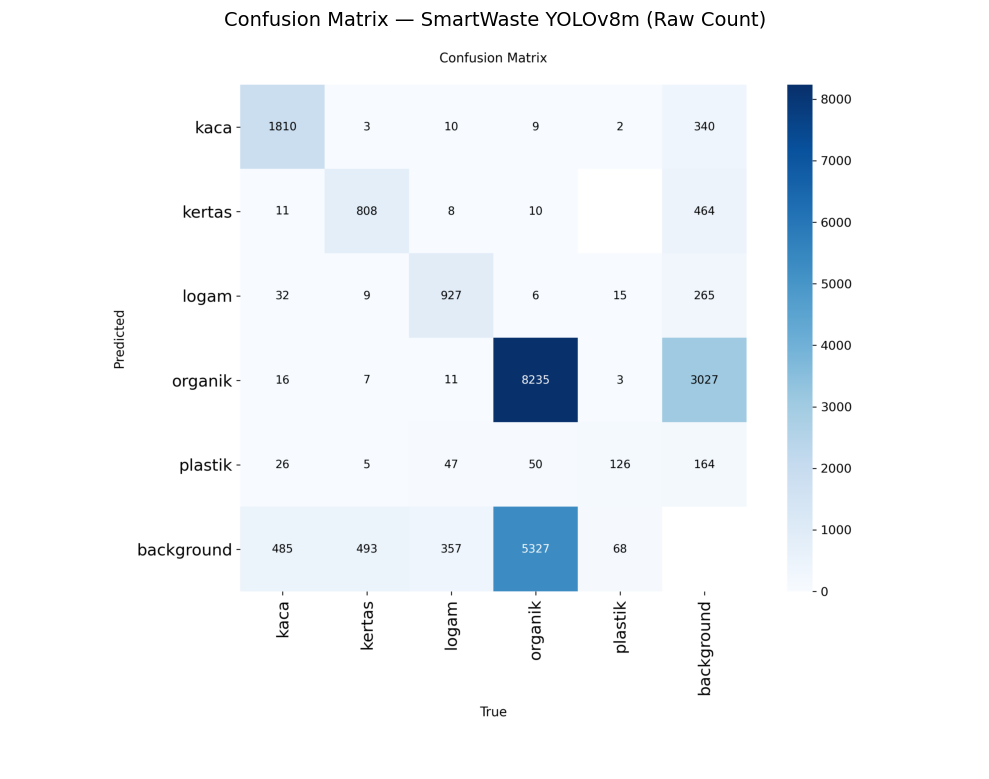

✅ Ditampilkan: runs/detect/smartwaste_yolov8m/confusion_matrix.png

2️⃣  Confusion Matrix (Normalized):


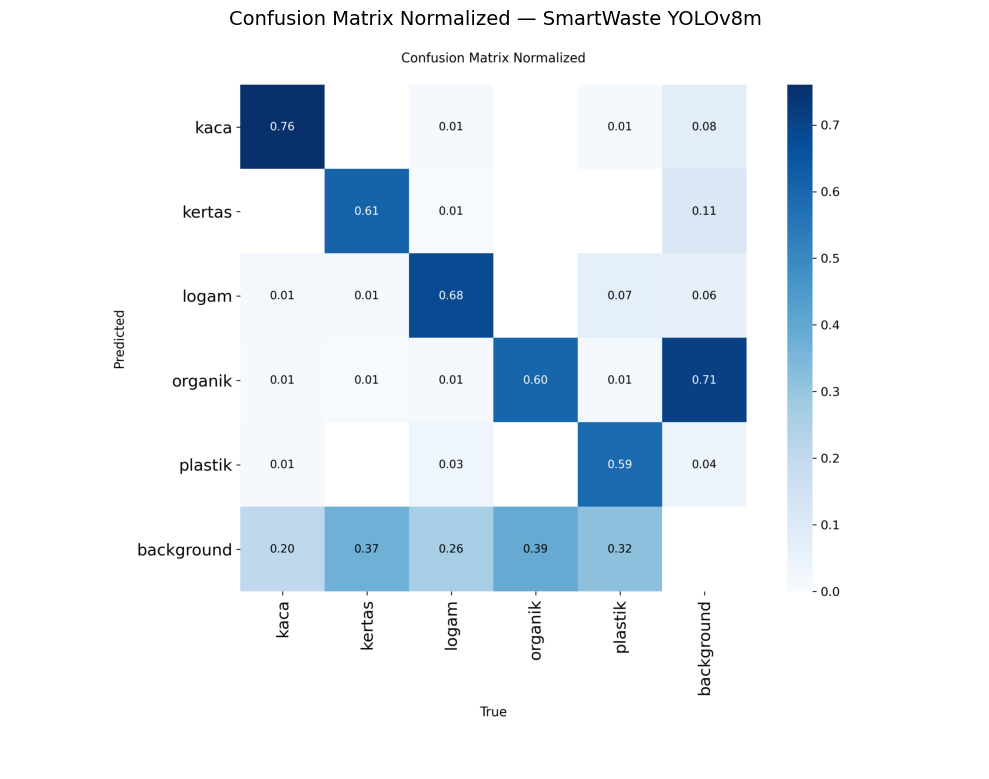

✅ Ditampilkan: runs/detect/smartwaste_yolov8m/confusion_matrix_normalized.png

💾 Menyimpan confusion matrix ke Google Drive...
   ✅ Tersimpan → /content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training/confusion_matrix_20260619_1412.png
   ✅ Tersimpan → /content/drive/MyDrive/SmartWaste_DatasetYoloV8/hasil_training/confusion_matrix_normalized_20260619_1412.png


In [ ]:
# ============================================================
# Cell R7 — Tampilkan Confusion Matrix
# ============================================================
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

RUNS_DIR = "runs/detect/smartwaste_yolov8m"

# Path ke confusion matrix
cm_path = os.path.join(RUNS_DIR, "confusion_matrix.png")
cm_norm_path = os.path.join(RUNS_DIR, "confusion_matrix_normalized.png")

def show_confusion_matrix(path, title):
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=14, pad=12)
        plt.tight_layout()
        plt.show()
        print(f"✅ Ditampilkan: {path}")
    else:
        print(f"⚠️  File tidak ditemukan: {path}")
        print("   Pastikan training sudah selesai dan file ada di folder runs.")

print("📊 Confusion Matrix — SmartWaste YOLOv8m\n")
print("1️⃣  Confusion Matrix (Raw Count):")
show_confusion_matrix(cm_path, "Confusion Matrix — SmartWaste YOLOv8m (Raw Count)")

print("\n2️⃣  Confusion Matrix (Normalized):")
show_confusion_matrix(cm_norm_path, "Confusion Matrix Normalized — SmartWaste YOLOv8m")

# Simpan confusion matrix ke Google Drive
print("\n💾 Menyimpan confusion matrix ke Google Drive...")
from datetime import datetime
import shutil

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
for fname, src_path in [("confusion_matrix.png", cm_path), ("confusion_matrix_normalized.png", cm_norm_path)]:
    if os.path.exists(src_path):
        dst = os.path.join(DRIVE_SAVE_DIR, f"{fname.replace('.png', '')}_{timestamp}.png")
        shutil.copy(src_path, dst)
        print(f"   ✅ Tersimpan → {dst}")
    else:
        print(f"   ⚠️  {fname} tidak ditemukan, skip.")

In [ ]:
# ============================================================
# Cell R8 — Simpan manual model ke Google Drive (opsional)
# Bisa dijalankan kapan saja, misalnya di tengah training atau setelah selesai
# ============================================================
import shutil, os
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUNS_DIR = "runs/detect/smartwaste_yolov8m/weights"

files_to_save = [
    (f"{RUNS_DIR}/best.pt",  f"best_manual_{timestamp}.pt"),
    (f"{RUNS_DIR}/last.pt",  f"last_manual_{timestamp}.pt"),
]

print("💾 Simpan manual ke Google Drive:")
for src, dst_name in files_to_save:
    if os.path.exists(src):
        dst = os.path.join(DRIVE_SAVE_DIR, dst_name)
        shutil.copy(src, dst)
        size_mb = os.path.getsize(src) / (1024 * 1024)
        print(f"   ✅ {dst_name} ({size_mb:.1f} MB)")
    else:
        print(f"   ⚠️  {src} belum ada (training belum sampai sini?)")

print(f"\n📁 Tersimpan di: SmartWaste_DatasetYoloV8/hasil_training/")

💾 Simpan manual ke Google Drive:
   ✅ best_manual_20260619_141245.pt (49.6 MB)
   ✅ last_manual_20260619_141245.pt (49.6 MB)

📁 Tersimpan di: SmartWaste_DatasetYoloV8/hasil_training/


In [ ]:
# ============================================================
# Cell R9 — Download best.pt dan grafik ke komputer lokal (opsional)
# ============================================================
from google.colab import files

best_model_path = "runs/detect/smartwaste_yolov8m/weights/best.pt"

if os.path.exists(best_model_path):
    files.download(best_model_path)
else:
    print(f"⚠️  {best_model_path} belum ada.")

if os.path.exists("yolo_training_history.png"):
    files.download("yolo_training_history.png")
else:
    print("⚠️  yolo_training_history.png belum ada — jalankan Cell R6 dulu.")

print("✅ Download selesai!")
print("📌 Taruh best.pt di folder project Flask: model/yolo/smartwaste_yolo.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!
📌 Taruh best.pt di folder project Flask: model/yolo/smartwaste_yolo.pt


---
## 💡 Tips Resume Training

| Situasi | Solusi |
|---------|--------|
| **Sesi Colab habis / disconnect** | Jalankan Cell R1 → R2 → R3 → R4 |
| **Ingin pilih checkpoint epoch tertentu** | Ubah `CHECKPOINT_FILENAME` di Cell R3 |
| **`resume=True` error** | Pastikan `name="smartwaste_yolov8m"` & `exist_ok=True` sudah diset |
| **Dataset lokal masih ada (tidak reset)** | Skip Cell R2, langsung R3 → R4 |
| **Training sudah selesai (100/100 epoch)** | Skip R4, langsung jalankan R5 → R9 |
| **Mau cek progres tanpa stop training** | Cell R8 aman dijalankan kapan saja, sel terpisah |

**File checkpoint yang diambil** (prioritas dari atas):
1. `last_YYYYMMDD_HHMMSS.pt` / `best_final_YYYYMMDD_HHMMSS.pt` — disimpan saat training selesai natural
2. `checkpoint_epochXXX_HHMM.pt` — disimpan auto-save setiap 10 epoch (pilih yang epoch-nya terbesar)
3. Contoh dari Drive kamu: `checkpoint_epoch060_2113.pt` ← paling baru saat ini

**Catatan:**
- Confidence threshold untuk webcam real-time: gunakan **0.4–0.5** agar tidak banyak false positive.
- Kalau mAP kelas `organik` rendah (<0.5), pertimbangkan menambah data dari dataset biological/food waste lain.
- Cell R5–R7 butuh variabel `model` yang sudah ter-load (dari Cell R4, atau load manual: `model = YOLO("path/ke/best.pt")` kalau training sudah selesai duluan).